# Customer Churn Analysis

## Project Objective
Analyze customer demographics, services, contract details, and account information to identify key factors influencing customer churn and generate business insights for improving customer retention.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Better chart style
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

## Data Cleaning

The dataset was examined for data quality issues, including incorrect data types, missing values, duplicate records, and inconsistent values. Necessary preprocessing steps were performed to prepare the data for analysis.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

### Observation

The `TotalCharges` column is stored as an object (string) instead of a numeric data type. This commonly occurs due to blank values or non-numeric entries within the column.

In [5]:
(df["TotalCharges"]== " ").sum()

np.int64(11)

### Investigation of Blank Values

Before converting the column to a numeric data type, inspect the records containing blank values to understand the cause of the inconsistency.

In [6]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
#Replace Blank Values
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

Check if they are replaced

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

Now convert the column

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [10]:
#verify that the column is now numeric
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

## Missing Value Analysis

In [11]:
# Check missing values in each column
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df[df["tenure"]==0].shape

(11, 21)

In [14]:
#Check whether these customers churned
df[df["tenure"]==0]["Churn"].value_counts()

Churn
No    11
Name: count, dtype: int64

In [15]:
#Check their contract types
df[df["tenure"]==0]["Contract"].value_counts()

Contract
Two year    10
One year     1
Name: count, dtype: int64

Can a customer with tenure = 0 have a One-Year or Two-Year contract?

That is highly unlikely in a real business.

A tenure of 0 months usually means a customer has just joined, but someone who has already signed a 1-year or 2-year contract should normally have a valid billing amount (TotalCharges), not a blank one

In [16]:
# Remove rows where TotalCharges is blank
df = df[df["TotalCharges"] != " "]

In [17]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Observation: The 11 records with blank TotalCharges belong to customers having tenure = 0. Since these records cannot provide meaningful billing information and represent a very small portion of the dataset, they were removed before further analysis

In [19]:
# Display the rows where TotalCharges is missing
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## Handling Missing Values

The missing values were investigated before applying any cleaning technique. Since the missing values were confined to the `TotalCharges` column and represented customers with `tenure = 0`, these records were removed to maintain data consistency for further analysis.

In [20]:
df=df.dropna()

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

## Duplicate Record Analysis

Checked the dataset for duplicate records to ensure data integrity before performing exploratory data analysis.

In [22]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset. Therefore, no duplicate removal was required.

# Exploratory Data Analysis (EDA)

Performed exploratory data analysis to understand customer behavior, identify churn patterns, and generate business insights through statistical summaries and visualizations.

## Churn Distribution Analysis

In [23]:
#Count Churned vs Retained Customers
df["Churn"].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [24]:
#Churn Percentage
(df["Churn"].value_counts(normalize=True)*100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

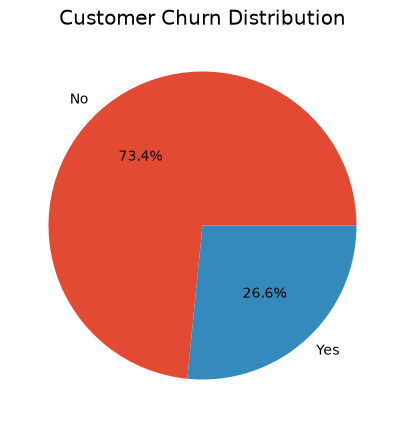

In [25]:
#Pie ChartPie Chart
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

### Observation

The visualization shows the proportion of customers who churned versus those who remained with the company. This provides a baseline understanding of customer retention and overall churn behavior.


Out of 7,032 customers, 5,163 (73.42%) remained with the company, while 1,869 (26.58%) discontinued the service. The dataset indicates that approximately one in four customers churned, highlighting a significant customer retention challenge that warrants further investigation.

## Gender-wise Churn Analysis

In [26]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

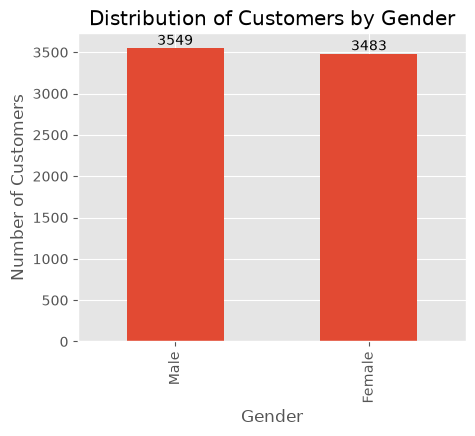

In [27]:
import matplotlib.pyplot as plt

ax = df["gender"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Distribution of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [28]:
import pandas as pd

pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


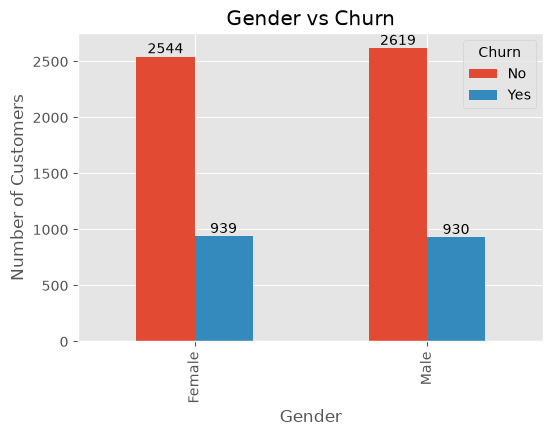

In [29]:
ax = pd.crosstab(df["gender"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

The dataset contains 3,549 male customers and 3,483 female customers, indicating an almost equal gender distribution. Churn levels are also comparable across both groups (930 males and 939 females), suggesting that gender does not appear to have a significant influence on customer churn.

## Senior Citizen vs Churn Analysis

In [30]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [31]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


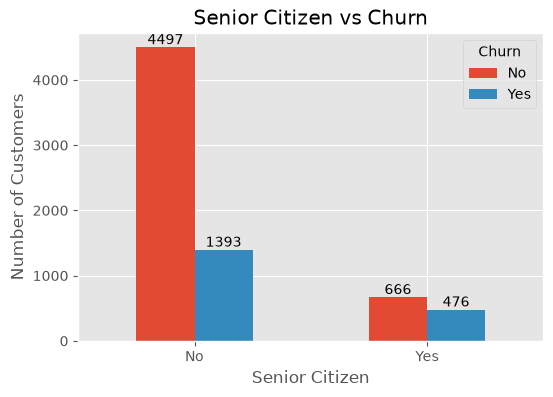

In [32]:
ax = pd.crosstab(df["SeniorCitizen"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

# Rename x-axis labels
plt.xticks([0,1], ["No", "Yes"], rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

The dataset contains 5,890 non-senior customers and 1,142 senior customers. Although senior citizens represent a smaller customer segment, they exhibit a substantially higher churn rate than non-senior customers. This indicates that senior citizens are more likely to discontinue the service and may require targeted retention strategies.

## Contract Type vs Churn Analysis

In [33]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [34]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


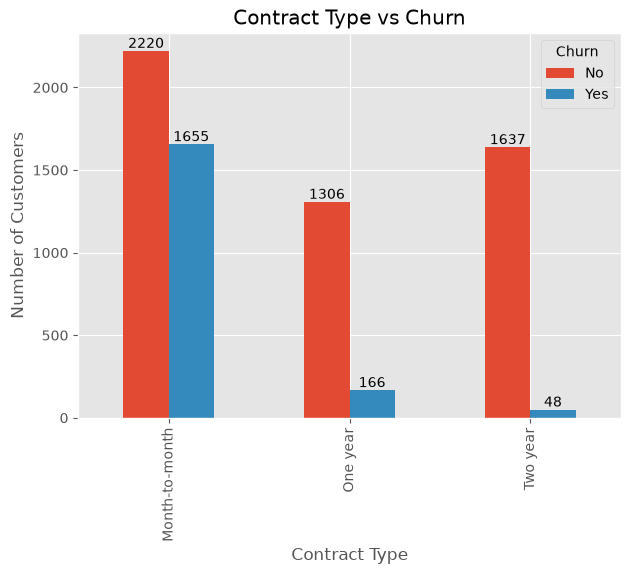

In [35]:
ax = pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Contract type has a strong impact on customer retention. Customers on month-to-month contracts exhibit the highest churn rate, while those on one-year and two-year contracts demonstrate significantly lower churn. The analysis suggests that longer contractual commitments are strongly associated with improved customer retention and reduced churn risk.

✅ Gender has minimal impact on churn.

✅ Senior citizens have a higher likelihood of churning.

✅ Contract type is the strongest factor influencing churn

## Tenure vs Churn Analysis

In [36]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

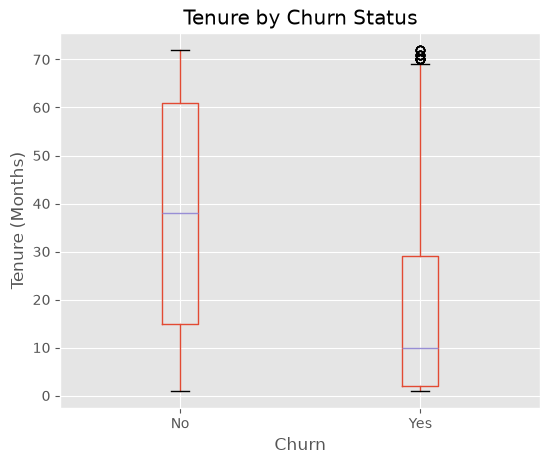

In [37]:
ax = df.boxplot(column="tenure", by="Churn", figsize=(6,5))

plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

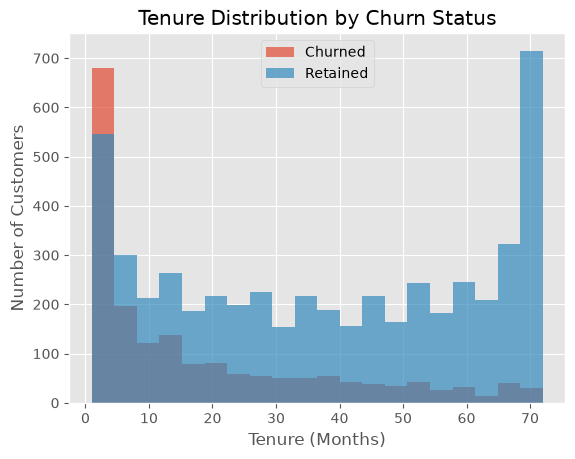

In [38]:
ax = df[df["Churn"]=="Yes"]["tenure"].plot(
    kind="hist",
    bins=20,
    alpha=0.7,
    label="Churned"
)

df[df["Churn"]=="No"]["tenure"].plot(
    kind="hist",
    bins=20,
    alpha=0.7,
    label="Retained"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

### Observation

Tenure exhibits a strong relationship with customer churn. Customers with shorter service durations are considerably more likely to discontinue the service, whereas long-tenure customers demonstrate significantly higher retention. The findings suggest that customer loyalty strengthens over time, emphasizing the importance of retention initiatives during the early stages of the customer lifecycle.

## Monthly Charges vs Churn Analysis

In [39]:
df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

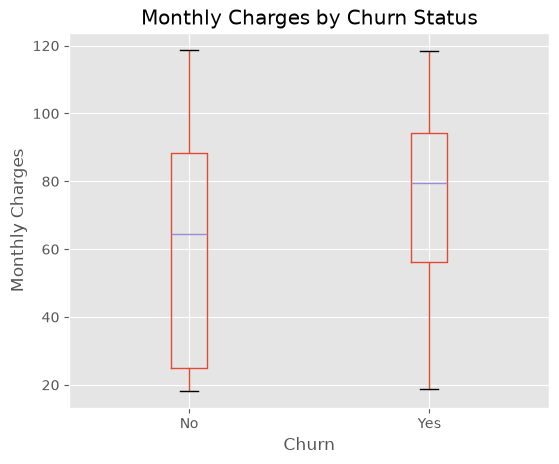

In [40]:
df.boxplot(column="MonthlyCharges", by="Churn", figsize=(6,5))

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

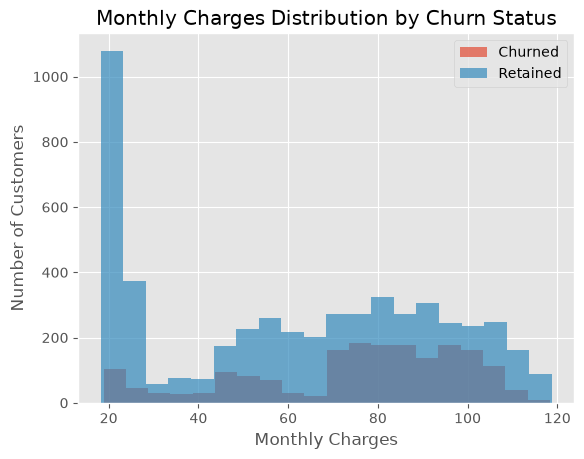

In [41]:
ax = df[df["Churn"]=="Yes"]["MonthlyCharges"].plot(
    kind="hist",
    bins=20,
    alpha=0.7,
    label="Churned"
)

df[df["Churn"]=="No"]["MonthlyCharges"].plot(
    kind="hist",
    bins=20,
    alpha=0.7,
    label="Retained"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

In [42]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


Business Insight

Customers paying higher monthly charges are more likely to churn, while customers with lower monthly charges tend to remain with the company. This suggests that pricing or expensive plans may contribute to customer churn.

Analyze Total Charges

In [43]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

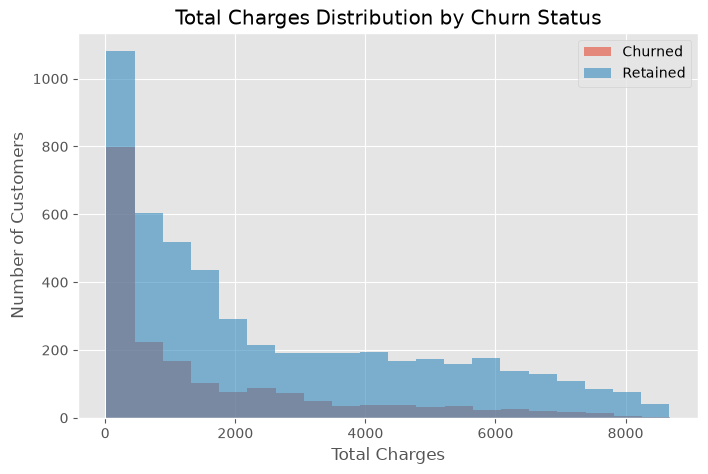

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df[df["Churn"]=="Yes"]["TotalCharges"],
         bins=20,
         alpha=0.6,
         label="Churned")

plt.hist(df[df["Churn"]=="No"]["TotalCharges"],
         bins=20,
         alpha=0.6,
         label="Retained")

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

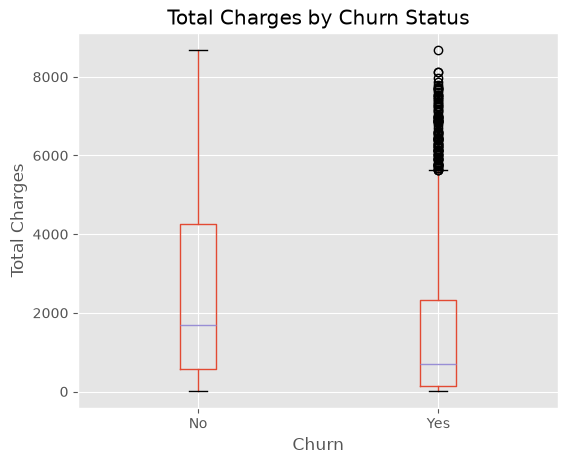

In [45]:
df.boxplot(column="TotalCharges", by="Churn", figsize=(6,5))

plt.title("Total Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [46]:
#Compare Churn Groups
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


Business Insight

Customers who have spent more money overall are less likely to leave because they have been with the company longer. Customers with lower Total Charges are more likely to churn since many leave within the first few months.

This matches our earlier finding:

Tenure ↑ → Churn ↓
Total Charges ↑ → Churn ↓
Monthly Charges ↑ → Churn ↑

These three variables are the strongest predictors we've found so far.

# Internet Service Analysis

### Objective
Analyze how different internet service types influence customer churn and identify which service has the highest churn rate.

In [47]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [48]:
#Churn by Internet Service
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [49]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


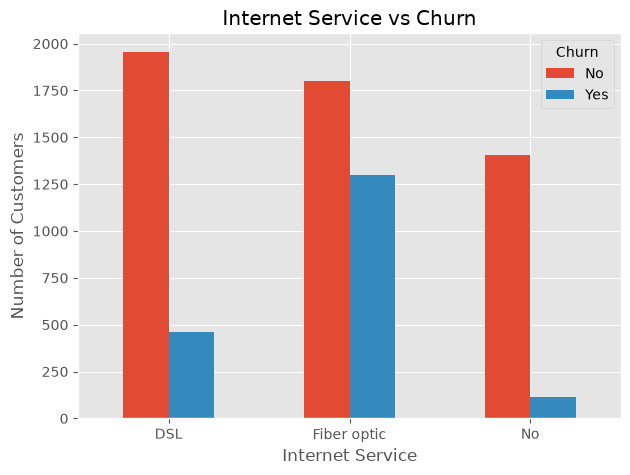

In [50]:
import matplotlib.pyplot as plt

pd.crosstab(df["InternetService"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Business Insight
Fiber Optic customers have the highest churn rate (41.9%), making them the most likely to leave.
DSL customers have a much lower churn rate (19%).
Customers with no internet service rarely churn (7.4%), indicating they are generally stable customers.
Possible Business Reasons
Fiber Optic plans may be more expensive, leading to higher customer dissatisfaction.
Customers using Fiber Optic may have higher expectations regarding speed and service quality.
Customers without internet service often subscribe only to basic telecom services, making them less likely to switch providers.

# Payment Method Analysis

### Objective
Analyze customer churn across different payment methods to identify which payment method is associated with the highest customer churn.# Payment Method Analysis


In [51]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [52]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [53]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.7,15.3
Electronic check,54.7,45.3
Mailed check,80.8,19.2


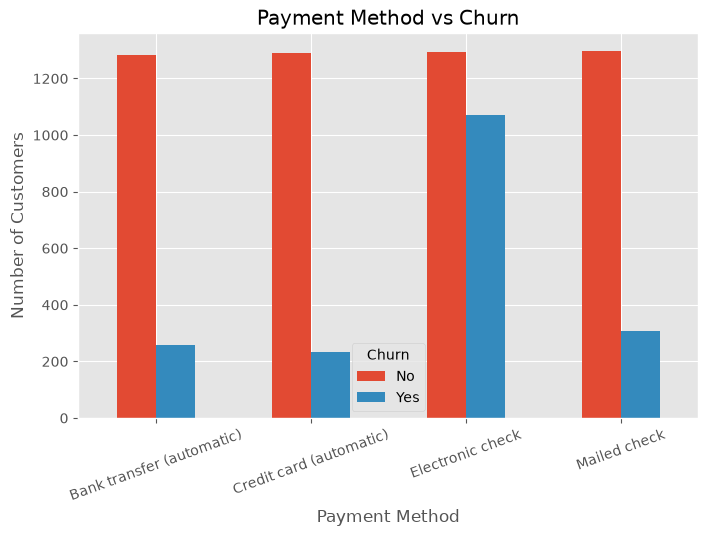

In [54]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

Business Insight

Electronic Check customers have the highest churn rate (45.3%), making them the most likely to leave the company.

Customers using automatic payment methods (Bank Transfer and Credit Card) have the lowest churn rates, indicating they are more loyal.

Customers using Mailed Check show a moderate churn rate (19.2%).


Possible Business Reasons

Customers using Electronic Check may experience less convenient payment processes or may be less committed to long-term services.

Customers enrolled in automatic payments are generally more engaged and less likely to cancel their subscriptions.

Encouraging customers to switch from Electronic Check to automatic payment methods could help reduce customer churn.

Key Insights Identified So Far
Feature	Key Finding
Tenure	Longer tenure → Lower churn
Monthly Charges	Higher monthly charges → Higher churn
Total Charges	Higher total charges → Lower churn
Contract	Month-to-month customers have the highest churn
Internet Service	Fiber Optic customers have the highest churn
Payment Method	Electronic Check customers have the highest churn

# Paperless Billing Analysis

### Objective
Analyze whether customers using paperless billing are more likely to churn compared to customers receiving paper bills.

In [55]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

In [56]:
pd.crosstab(df["PaperlessBilling"], df["Churn"])

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [57]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.6,16.4
Yes,66.4,33.6


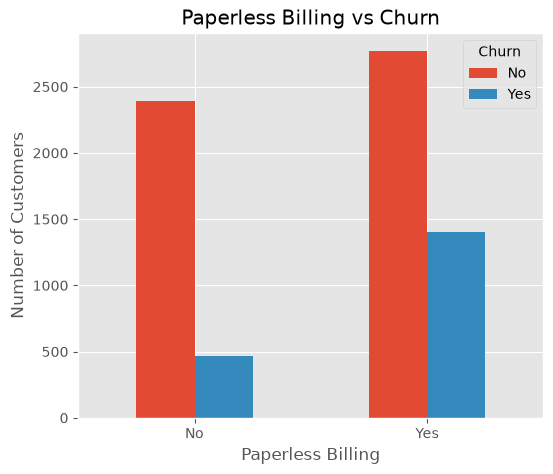

In [58]:
import matplotlib.pyplot as plt

pd.crosstab(df["PaperlessBilling"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Paperless Billing vs Churn")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

## Business Insight

- Customers using **Paperless Billing** have a significantly higher churn rate (**33.6%**) compared to customers who do not use Paperless Billing (**16.4%**).
- More than **one-third of paperless billing customers** have left the company, whereas only about **one-sixth of non-paperless billing customers** have churned.
- This indicates a strong association between **Paperless Billing** and customer churn.

### Recommendation
- The company should closely monitor customers enrolled in **Paperless Billing**, especially those with **month-to-month contracts**.
- Offering loyalty rewards, personalized retention offers, or encouraging customers to switch to longer-term contracts may help reduce churn among these customers.

# Online Security Analysis

### Objective
Analyze whether customers who subscribe to the Online Security service are less likely to churn compared to those who do not.

In [59]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [60]:
pd.crosstab(df["OnlineSecurity"], df["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2036,1461
No internet service,1407,113
Yes,1720,295


In [61]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6


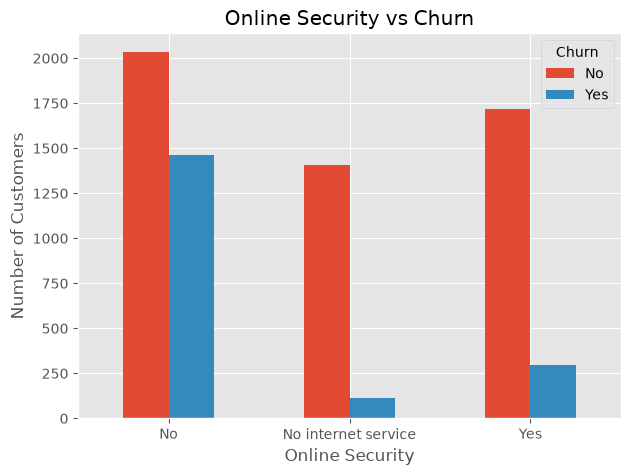

In [62]:
pd.crosstab(df["OnlineSecurity"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Online Security vs Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

## Online Security Analysis

### Customer Distribution

| Online Security | Customers |
|----------------|----------:|
| No | **3497** |
| Yes | **2015** |
| No Internet Service | **1520** |

### Churn Rate

| Online Security | Churn Rate |
|----------------|-----------:|
| No | **41.8%** |
| Yes | **14.6%** |
| No Internet Service | **7.4%** |

## Business Insight

- Customers **without Online Security** have the **highest churn rate (41.8%)**, making them the most likely to leave the company.
- Customers who subscribe to **Online Security** have a much lower churn rate (**14.6%**), indicating that this service helps improve customer retention.
- Customers with **No Internet Service** have the lowest churn rate (**7.4%**), suggesting they are generally stable customers.

### Recommendation

- Promote **Online Security** as a value-added service to customers who do not currently subscribe.
- Offer bundled packages or discounts that include Online Security to improve customer satisfaction and reduce churn.
- Prioritize retention campaigns for customers who have internet service but have not subscribed to Online Security, as they represent the highest-risk group.

# Tech Support Analysis

### Objective
Analyze whether customers who subscribe to Tech Support are less likely to churn compared to customers who do not.

In [63]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [64]:
pd.crosstab(df["TechSupport"], df["Churn"])

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


In [65]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


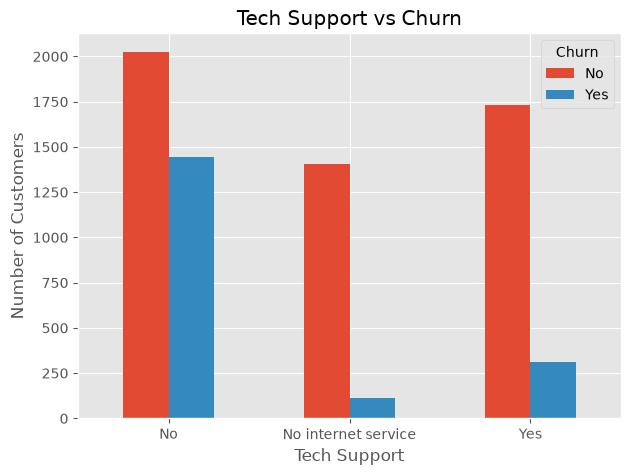

In [66]:

pd.crosstab(df["TechSupport"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Tech Support vs Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

## Tech Support Analysis

### Customer Distribution

| Tech Support | Customers |
|--------------|----------:|
| No | **3472** |
| Yes | **2040** |
| No Internet Service | **1520** |

### Churn Rate

| Tech Support | Churn Rate |
|--------------|-----------:|
| No | **41.6%** |
| Yes | **15.2%** |
| No Internet Service | **7.4%** |

## Business Insight

- Customers **without Tech Support** have the **highest churn rate (41.6%)**, making them the most likely to leave the company.
- Customers who subscribe to **Tech Support** have a significantly lower churn rate (**15.2%**), indicating that technical assistance plays an important role in customer retention.
- Customers with **No Internet Service** have the lowest churn rate (**7.4%**), showing they are relatively stable customers.

### Recommendation

- Encourage customers to subscribe to **Tech Support** through bundled service plans or promotional offers.
- Identify customers with internet service but no Tech Support and target them with retention campaigns.
- Improving customer access to technical assistance may increase customer satisfaction and reduce churn.

# Online Backup Analysis

### Objective
Analyze whether customers who subscribe to the Online Backup service are less likely to churn compared to customers who do not.

In [67]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [68]:
pd.crosstab(df["OnlineBackup"], df["Churn"])

Churn,No,Yes
OnlineBackup,,
No,1854,1233
No internet service,1407,113
Yes,1902,523


In [69]:
pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
OnlineBackup,,
No,60.1,39.9
No internet service,92.6,7.4
Yes,78.4,21.6


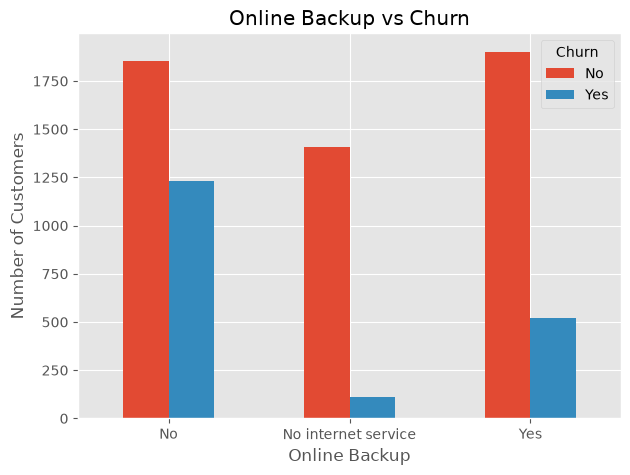

In [70]:
pd.crosstab(df["OnlineBackup"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Online Backup vs Churn")
plt.xlabel("Online Backup")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

## Online Backup Analysis

### Customer Distribution

| Online Backup | Customers |
|---------------|----------:|
| No | **3,087** |
| Yes | **2,425** |
| No Internet Service | **1,520** |

### Churn Rate

| Online Backup | Churn Rate |
|---------------|-----------:|
| No | **39.9%** |
| Yes | **21.6%** |
| No Internet Service | **7.4%** |

## Business Insight

- Customers **without Online Backup** have a **higher churn rate (39.9%)** compared to customers who subscribe to the service (**21.6%**).
- Although Online Backup reduces churn, its impact is **not as strong** as services like **Online Security** or **Tech Support**.
- Customers with **No Internet Service** have the lowest churn rate (**7.4%**), indicating they are generally more stable.

### Recommendation

- Promote **Online Backup** as part of bundled internet service packages.
- Encourage customers without Online Backup to subscribe through discounts or promotional offers.
- Focus retention campaigns on customers who have internet service but have not subscribed to Online Backup, as they are more likely to churn.

# Device Protection Analysis

### Objective
Analyze whether customers who subscribe to Device Protection are less likely to churn than customers who do not.

In [71]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [72]:
pd.crosstab(df["DeviceProtection"], df["Churn"])

Churn,No,Yes
DeviceProtection,,
No,1883,1211
No internet service,1407,113
Yes,1873,545


In [73]:
pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
DeviceProtection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5


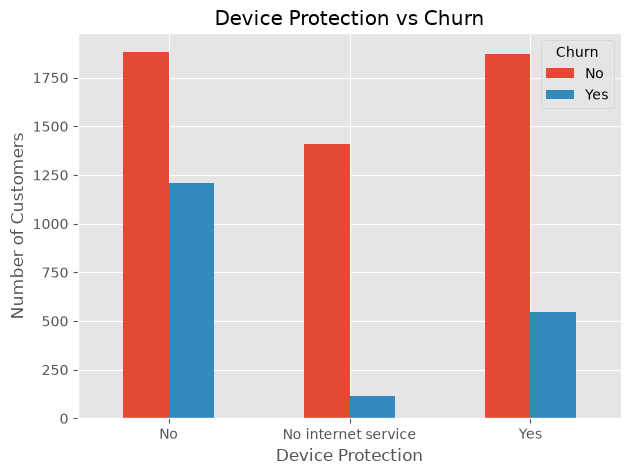

In [74]:
pd.crosstab(df["DeviceProtection"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Device Protection vs Churn")
plt.xlabel("Device Protection")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

# Device Protection Analysis

### Customer Distribution

| Device Protection | Customers |
|-------------------|----------:|
| No | **3,094** |
| Yes | **2,418** |
| No Internet Service | **1,520** |

### Churn Rate

| Device Protection | Churn Rate |
|-------------------|-----------:|
| No | **39.1%** |
| Yes | **22.5%** |
| No Internet Service | **7.4%** |

## Business Insight

- Customers **without Device Protection** have a significantly higher churn rate (**39.1%**) than customers who subscribe to Device Protection (**22.5%**).
- Customers using Device Protection are more likely to remain with the company, indicating that value-added services improve customer retention.
- Customers with **No Internet Service** continue to have the lowest churn rate (**7.4%**), showing they are generally stable customers.

### Recommendation

- Encourage customers without Device Protection to subscribe through bundle offers and promotional discounts.
- Include Device Protection in premium service packages to increase customer loyalty.
- Prioritize retention campaigns for internet-service customers who have not subscribed to Device Protection, as they have a higher likelihood of churning.

# Data Preprocessing

### Objective

Prepare the dataset for machine learning by converting categorical variables into numerical values and removing unnecessary columns.

In [75]:
#Drop Customer ID

df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

# Categorical Data Encoding

### Objective

Convert categorical columns into numerical values so that machine learning algorithms can process the dataset.

In [77]:
#Check Unique Values
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())
    print("-" * 40)

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------------------------------------
InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
----------------------------------------
OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
----------------------------------------
DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

C:\Users\Windows 10 Pro\AppData\Local\Temp\ipykernel_3500\892994878.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [78]:
#Encode Binary Columns

#The following columns have only two values and can be converted to numbers:

#gender
#Partner
#Dependents
#PhoneService
#PaperlessBilling
#ChurnEncode Binary Columns


df["gender"] = df["gender"].map({"Female":0,"Male":1})

df["Partner"] = df["Partner"].map({"No":0,"Yes":1})

df["Dependents"] = df["Dependents"].map({"No":0,"Yes":1})

df["PhoneService"] = df["PhoneService"].map({"No":0,"Yes":1})

df["PaperlessBilling"] = df["PaperlessBilling"].map({"No":0,"Yes":1})

df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [79]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## One-Hot Encoding

### Objective

Convert multi-category categorical variables into numerical features using One-Hot Encoding.

In [80]:
#Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True,
    dtype=int
)

In [81]:
#Verify the Dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [82]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Yes   

# Final Data Validation

### Objective

Verify that the dataset is clean and ready for machine learning by checking for missing values and duplicate records.

In [83]:
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [84]:
df.duplicated().sum()

np.int64(22)

In [85]:
df[df.duplicated(keep=False)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
22,1,0,0,0,1,1,0,20.15,20.15,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1
100,1,0,0,0,1,1,0,20.20,20.20,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1
542,0,0,0,0,1,1,0,19.55,19.55,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1
646,1,0,0,0,1,1,1,45.70,45.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
662,1,0,0,0,1,1,0,20.05,20.05,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1
690,1,0,0,0,1,1,1,20.45,20.45,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1
964,1,0,0,0,1,1,1,45.70,45.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
976,1,0,0,0,1,1,1,69.90,69.90,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1243,1,0,0,0,1,1,0,45.30,45.30,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1338,1,0,0,0,1,1,0,20.15,20.15,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1


## Duplicate Record Investigation

- After removing the `customerID` column, the dataset shows **22 duplicate rows**.
- These rows are not necessarily data quality issues because multiple customers can have identical demographic and service information.
- Since the unique customer identifier was removed, these records likely represent different customers with the same attributes.
- Therefore, the duplicate rows will be **retained** to avoid losing valid customer information.

# Save Cleaned Dataset

### Objective

Save the cleaned and preprocessed customer churn dataset for future analysis and machine learning.

In [86]:
import os
os.getcwd()

'c:\\Users\\Windows 10 Pro\\Desktop\\Customer-Churn-Analysis\\notebooks'

In [87]:
df.to_csv("../data/processed/customer_churn_cleaned.csv", index=False)

In [88]:
os.path.exists("../data/processed/customer_churn_cleaned.csv")

True

# Machine Learning

## Objective

Build a machine learning model to predict whether a customer is likely to churn based on demographic, service usage, and billing information.

In [89]:
#Separate Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [90]:
#Verify
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [91]:
#Split the Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
#verify the shapes of the training and testing sets
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (5625, 30)
Testing Features  : (1407, 30)
Training Target   : (5625,)
Testing Target    : (1407,)


## Business Insight

- The dataset was divided into **80% training data** and **20% testing data**.
- Stratified sampling was applied to preserve the original churn distribution in both datasets.
- The training dataset will be used to build predictive models, while the testing dataset will be used to evaluate model performance on unseen customer data.

# Logistic Regression

## Objective

Build a Logistic Regression model to predict customer churn and evaluate its performance using classification metrics.

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [94]:
# Train Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

c:\Users\Windows 10 Pro\Desktop\Customer-Churn-Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [95]:
#Make Predictions
y_pred = lr_model.predict(X_test)

In [96]:
#Check Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8031272210376688


In [97]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [159 215]]


In [98]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Business Insight

- The Logistic Regression model achieved an **accuracy of 80.31%**, demonstrating strong baseline performance for customer churn prediction.
- The model correctly identified **915 non-churn customers** and **215 churn customers**, while misclassifying **277 customers**.
- The churn class achieved a **Precision of 65%**, **Recall of 57%**, and an **F1-Score of 61%**, indicating that although the model performs well overall, it misses a portion of customers who are likely to churn.
- These results suggest that additional machine learning models should be evaluated to improve churn detection and maximize customer retention opportunities.

# Decision Tree Classifier

## Objective

Train a Decision Tree Classifier to predict customer churn and compare its performance with the Logistic Regression model.

In [99]:
#Import Library
from sklearn.tree import DecisionTreeClassifier

In [100]:
# Train Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [101]:
#Make Predictions
y_pred_dt = dt_model.predict(X_test)

In [102]:
#Model Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7128642501776831


In [103]:
#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[834 199]
 [205 169]]


In [104]:
#Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1033
           1       0.46      0.45      0.46       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



## Business Insight

- The Decision Tree model achieved an **accuracy of 71.29%**, which is lower than the Logistic Regression model.
- While the model successfully identified many non-churn customers, its ability to detect churn customers remained limited, with a **Recall of 45%** and an **F1-Score of 46%**.
- Compared to Logistic Regression, the Decision Tree produced more misclassifications, indicating lower generalization performance on unseen customer data.
- These findings suggest that more robust ensemble methods, such as Random Forest, should be evaluated to improve prediction accuracy and churn detection.

# Random Forest Classifier

## Objective

Train a Random Forest Classifier to improve churn prediction by combining multiple decision trees and compare its performance with the previous models.

In [105]:
from sklearn.ensemble import RandomForestClassifier

In [106]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [107]:
y_pred_rf = rf_model.predict(X_test)

In [108]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7853589196872779


In [109]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[918 115]
 [187 187]]


In [110]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407



# Model Comparison

## Business Insight

- Three machine learning models were evaluated to predict customer churn: Logistic Regression, Decision Tree, and Random Forest.
- **Logistic Regression** achieved the highest overall accuracy (**80.31%**) and delivered the best balance between Precision, Recall, and F1-Score for churn prediction.
- **Random Forest** performed competitively with **78.54% accuracy**, but showed lower Recall and F1-Score for churn customers.
- **Decision Tree** recorded the lowest performance (**71.29% accuracy**) and produced the highest number of misclassifications.
- Based on the evaluation metrics, **Logistic Regression was selected as the final model** for customer churn prediction due to its superior predictive performance and better generalization on unseen customer data.

# Feature Importance

## Objective

Identify the most influential features contributing to customer churn prediction using the Random Forest model.

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.198838
4,tenure,0.171546
7,MonthlyCharges,0.168485
28,PaymentMethod_Electronic check,0.039660
11,InternetService_Fiber optic,0.035149
0,gender,0.028965
26,Contract_Two year,0.026683
14,OnlineSecurity_Yes,0.026053
6,PaperlessBilling,0.025548
20,TechSupport_Yes,0.023722


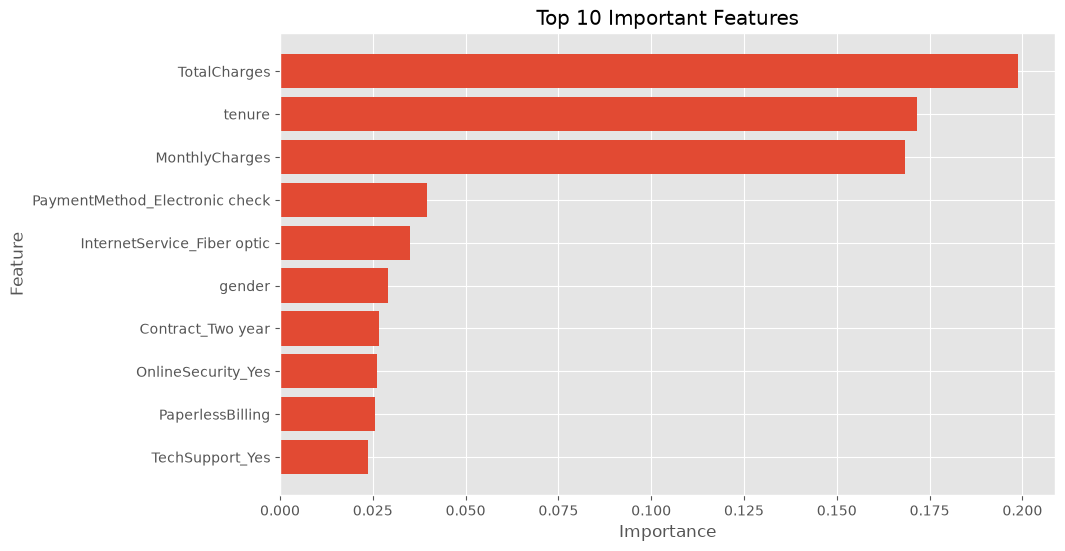

In [112]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.show()

# Save Best Model

## Objective

Save the best-performing machine learning model for future predictions and deployment.

In [113]:
import os

os.makedirs("../models", exist_ok=True)

In [114]:
import joblib

joblib.dump(lr_model, "../models/customer_churn_model.pkl")

['../models/customer_churn_model.pkl']

In [121]:
import os

os.listdir("../models")

['customer_churn_model.pkl']